# Dataset: diabetes_012_health_indicators_BRFSS2015.csv

## Visão Geral

Este dataset é derivado da **Behavioral Risk Factor Surveillance System (BRFSS) 2015**, uma pesquisa anual conduzida pelo **CDC (Centers for Disease Control and Prevention)** nos Estados Unidos. O objetivo é coletar dados sobre comportamentos de risco, condições crônicas de saúde e uso de serviços preventivos da população americana.

- **Linhas:** 253.680 respondentes
- **Colunas:** 22
- **Valores ausentes:** Nenhum (dataset já limpo)
- **Tipos:** Majoritariamente variáveis binárias e categóricas ordinais (float64)

---

## Variável-Alvo

| Coluna | Tipo | Descrição |
|---|---|---|
| `Diabetes_012` | Categórica (0, 1, 2) | **0** = sem diabetes (ou somente gestacional) / **1** = pré-diabetes / **2** = diabetes diagnosticada |

---

## Features: Condições Clínicas

| Coluna | Tipo | Descrição |
|---|---|---|
| `HighBP` | Binária (0/1) | Hipertensão arterial diagnosticada — 0: não / 1: sim |
| `HighChol` | Binária (0/1) | Colesterol alto diagnosticado — 0: não / 1: sim |
| `CholCheck` | Binária (0/1) | Realizou exame de colesterol nos últimos 5 anos — 0: não / 1: sim |
| `BMI` | Inteiro | Índice de Massa Corporal (IMC) |
| `Stroke` | Binária (0/1) | Já teve AVC — 0: não / 1: sim |
| `HeartDiseaseorAttack` | Binária (0/1) | Doença coronariana ou infarto do miocárdio — 0: não / 1: sim |
| `DiffWalk` | Binária (0/1) | Dificuldade séria para caminhar ou subir escadas — 0: não / 1: sim |

---

## Features: Estilo de Vida

| Coluna | Tipo | Descrição |
|---|---|---|
| `Smoker` | Binária (0/1) | Fumou ao menos 100 cigarros na vida (equivalente a 5 maços) — 0: não / 1: sim |
| `PhysActivity` | Binária (0/1) | Praticou atividade física nos últimos 30 dias (fora do trabalho) — 0: não / 1: sim |
| `Fruits` | Binária (0/1) | Consome frutas ao menos uma vez por dia — 0: não / 1: sim |
| `Veggies` | Binária (0/1) | Consome vegetais ao menos uma vez por dia — 0: não / 1: sim |
| `HvyAlcoholConsump` | Binária (0/1) | Consumo elevado de álcool (homens: >14 doses/semana; mulheres: >7 doses/semana) — 0: não / 1: sim |

---

## Features: Acesso à Saúde

| Coluna | Tipo | Descrição |
|---|---|---|
| `AnyHealthcare` | Binária (0/1) | Possui algum plano ou cobertura de saúde — 0: não / 1: sim |
| `NoDocbcCost` | Binária (0/1) | Precisou de médico no último ano mas não foi por causa do custo — 0: não / 1: sim |

---

## Features: Saúde Geral (Auto-declarada)

| Coluna | Tipo | Descrição |
|---|---|---|
| `GenHlth` | Ordinal (1–5) | Avaliação geral da saúde — 1: excelente / 2: muito boa / 3: boa / 4: regular / 5: ruim |
| `MentHlth` | Inteiro (0–30) | Dias no último mês em que a saúde mental estava ruim (estresse, depressão, etc.) |
| `PhysHlth` | Inteiro (0–30) | Dias no último mês em que a saúde física estava ruim (doença ou lesão) |

---

## Features: Demográficas

| Coluna | Tipo | Descrição |
|---|---|---|
| `Sex` | Binária (0/1) | Sexo — 0: feminino / 1: masculino |
| `Age` | Ordinal (1–13) | Faixa etária — 1: 18–24 anos / 2: 25–29 / ... / 13: 80 anos ou mais (incrementos de ~5 anos) |
| `Education` | Ordinal (1–6) | Nível de escolaridade — 1: nunca estudou / 2: fundamental incompleto / ... / 6: ensino superior completo |
| `Income` | Ordinal (1–8) | Faixa de renda anual — 1: < $10.000 / ... / 8: ≥ $75.000 |

---

## Notas para o Profiling

- **Desbalanceamento de classes:** A variável-alvo `Diabetes_012` é fortemente desbalanceada — a classe 0 (sem diabetes) é majoritária, classe 1 (pré-diabetes) é minoria expressiva, e classe 2 (diabetes) é intermediária. Vale checar a distribuição logo de início.
- **Sem missings declarados**, mas vale confirmar com `df.isnull().sum()` e verificar se há valores fora dos ranges esperados (ex: BMI extremo, Age = 0).
- **Variáveis ordinais disfarçadas de numéricas:** `GenHlth`, `Age`, `Education` e `Income` são ordinais e não devem ser tratadas como contínuas em certos modelos.
- **Todas as colunas são float64** no CSV original — conversão para tipos mais adequados (`int`, `category`) é recomendada no início do notebook.

#### Agora começo a análise exploratória dos dados afim de entender a distribuição e relação que eles apresentam.
faço a importação do dataset limpo e vejo algumas estatísticas iniciais

In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Estudos\Projetos\diabetes-analysis\01_data\processed\diabetes_012_processed.csv')
df.describe()

,Diabetes_012,BMI,GenHlth,MentHlth,PhysHlth,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,28.382364,2.511392,3.184772,4.242081,8.032119,5.050434,6.053875
std,0.698160,6.608694,1.068477,7.412847,8.717951,3.054220,0.985774,2.071148
min,0.000000,12.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,24.000000,2.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,27.000000,2.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,31.000000,3.000000,2.000000,3.000000,10.000000,6.000000,8.000000
max,2.000000,98.000000,5.000000,30.000000,30.000000,13.000000,6.000000,8.000000


Vou começar entendendo a distribuição da variável alvo

In [2]:
print(df['Diabetes_012'].value_counts(normalize=True) * 100)

Diabetes_012
0    84.241170
2    13.933302
1     1.825528
Name: proportion, dtype: float64


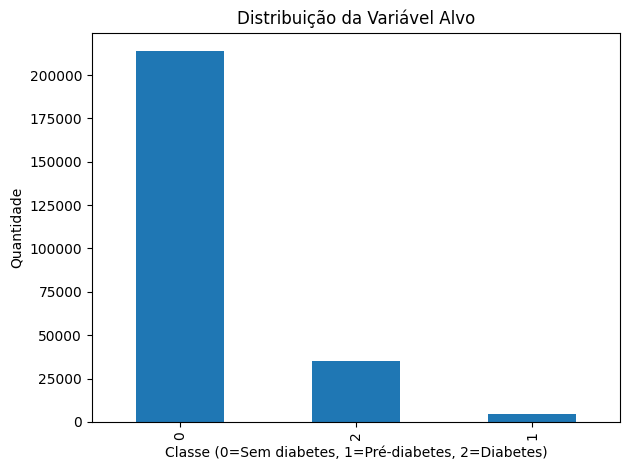

In [3]:
import matplotlib.pyplot as plt

df['Diabetes_012'].value_counts().plot(kind='bar')
plt.title('Distribuição da Variável Alvo')
plt.xlabel('Classe (0=Sem diabetes, 1=Pré-diabetes, 2=Diabetes)')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.savefig(r'C:\Estudos\Projetos\diabetes-analysis\05_reports\images\Distribuição da Variável Alvo.png', dpi=200, bbox_inches='tight')
plt.show()

Preciso entender a correlação das variáveis desse dataframe  
Decido montar um heatmap para entender quais outras variáveis tem correlação com nosso alvo

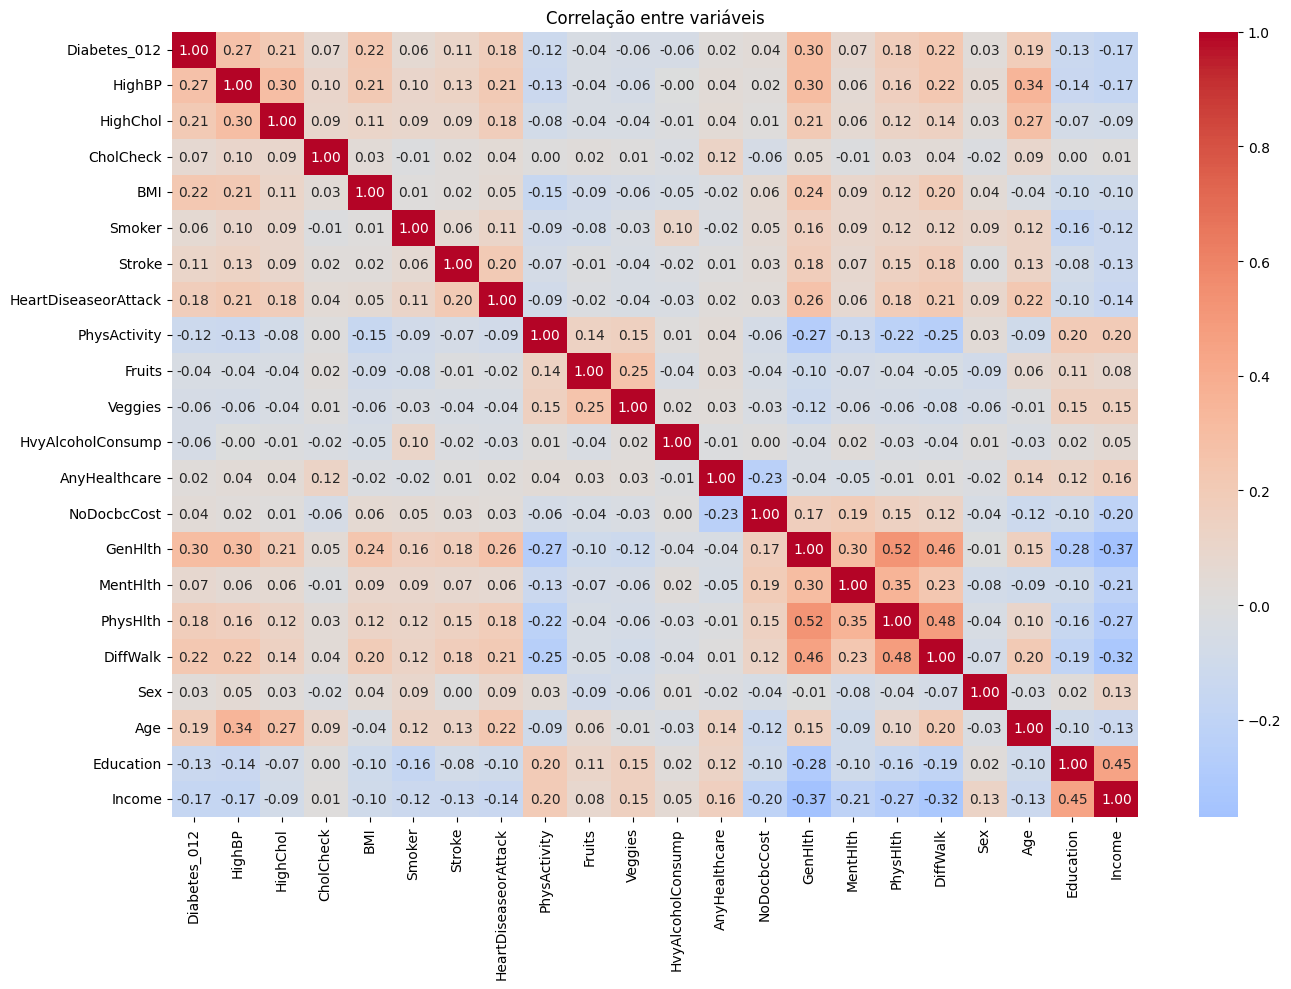

In [4]:
import seaborn as sns

# Preciso transformar as colunas categoricas em numéricas para construir o heatmap
df_num = df.apply(lambda x: x.cat.codes if hasattr(x, 'cat') else x)

plt.figure(figsize=(14, 10))
sns.heatmap(df_num.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis')
plt.tight_layout()
plt.savefig(r'C:\Estudos\Projetos\diabetes-analysis\05_reports\images\Correlação entre variáveis.png', dpi=200, bbox_inches='tight')
plt.show()

Notamos uma possível correlação das variáveis HighBP e GenHlth

Vemos o percentual da correlação da variável HighBP

In [5]:
df.groupby('HighBP')['Diabetes_012'].value_counts(normalize=True).unstack()

Diabetes_012,0,1,2
HighBP,,,
False,0.927788,0.011860,0.060352
True,0.728776,0.026767,0.244457


Demonstra que quem tem pressão arterial alta têm 4 vezes mais chance de ter diabetes

Vemos também o percentual da correlação da variável GenHlth

In [6]:
df.groupby('GenHlth')['Diabetes_012'].value_counts(normalize=True).unstack()

Diabetes_012,0,1,2
GenHlth,,,
1,0.967924,0.006910,0.025166
2,0.914743,0.013628,0.071629
3,0.799262,0.022843,0.177894
4,0.657428,0.032468,0.310105
5,0.592004,0.029054,0.378942


Também demonstra que quem avalia sua saúde como ruim têm 15 vezes mais chance de ter diabetes

Enquanto pessoas com o salário anual maior, educação melhor e é praticante de atividades físicas tendem a não ter diabetes  

Isso pode responder a pergunta 2  
"A prática de atividade física reduz o risco de diagnóstico?"

Agora quero observar a correlação das variáveis Income, AnyHealthcare e NoDocbcCost

In [7]:
df.groupby(['AnyHealthcare', 'NoDocbcCost'])['Income'].value_counts(normalize=True).unstack()

Income                            1         2         3         4         5  \
AnyHealthcare NoDocbcCost                                                     
False         False        0.081271  0.068768  0.117760  0.144552  0.144935   
              True         0.149159  0.113999  0.162481  0.167722  0.141516   
True          False        0.031525  0.040265  0.054716  0.071362  0.097221   
              True         0.084292  0.100328  0.121848  0.131982  0.135559   

Income                            6         7         8  
AnyHealthcare NoDocbcCost                                
False         False        0.164838  0.128732  0.149145  
              True         0.132562  0.081240  0.051321  
True          False        0.143259  0.176361  0.385290  
              True         0.143726  0.133949  0.148316

Olhando a linha True/False (tem plano, conseguiu ir ao médico), vemos que a proporção sobe de 0.03 na renda 1 para 0.38 na renda 8 — confirmando que maior renda está associada a maior acesso a cuidados.

E isso responde a pergunta 3  
"Existe correlação entre nível de renda e acesso a cuidados preventivos?"

Agora preciso entender a distribuição das idades  
- Primeiro vejo qual o percentual de diabetes para cada faixa de idade
- Depois gero um grafico representando o mesmo percentual ajudando no entendimento

In [8]:
prevalencia_idade = df.groupby('Age')['Diabetes_012'].value_counts(normalize=True).unstack()
prevalencia_idade

Diabetes_012,0,1,2
Age,,,
1,0.982632,0.003684,0.013684
2,0.974467,0.007107,0.018426
3,0.965297,0.006473,0.028230
4,0.944440,0.010273,0.045287
5,0.924862,0.010089,0.065049
6,0.896362,0.015742,0.087895
7,0.866763,0.015885,0.117352
8,0.843896,0.017839,0.138265
9,0.806431,0.021117,0.172452


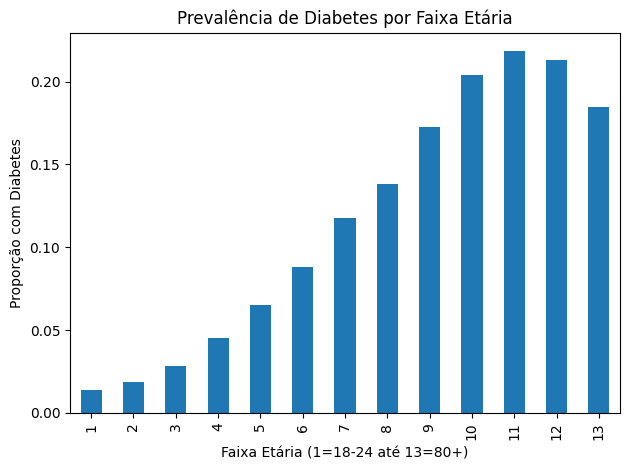

In [9]:
prevalencia_idade[2].plot(kind='bar')
plt.title('Prevalência de Diabetes por Faixa Etária')
plt.xlabel('Faixa Etária (1=18-24 até 13=80+)')
plt.ylabel('Proporção com Diabetes')
plt.tight_layout()
plt.savefig(r'C:\Estudos\Projetos\diabetes-analysis\05_reports\images\Prevalência de Diabetes por Faixa Etária.png', dpi=200, bbox_inches='tight')
plt.show()

A faixa de idade 11 (70-74 anos) tem maior tendência a diabetes, seguido das faixas 12 e 10  

Isso responde a pergunta 1  
"Quais faixas etárias têm maior prevalência de diabetes?" 

Vamos olhar novamente para o BMI, mas dessa vez quero o olhar para relação com a variável alvo

In [10]:
prevalencia_bmi = df.groupby('BMI')['Diabetes_012'].value_counts(normalize=True).unstack()
prevalencia_bmi

Diabetes_012,0,1,2
BMI,,,
12,1.000000,NaN,NaN
13,0.857143,0.047619,0.095238
14,0.878049,0.024390,0.097561
15,0.909091,NaN,0.090909
16,0.936782,0.005747,0.057471
...,...,...,...
91,1.000000,NaN,NaN
92,0.843750,NaN,0.156250
95,0.916667,NaN,0.083333


Agora vamos montar um gráfico de linhas para representar essa prevalência

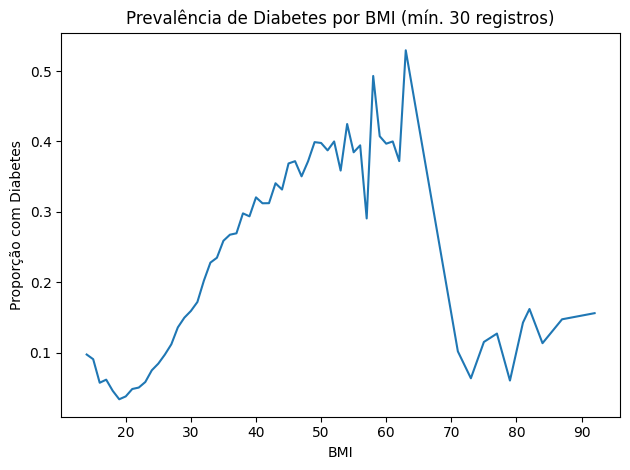

In [11]:
contagem_bmi = df['BMI'].value_counts()

bmi_confiavel = contagem_bmi[contagem_bmi >= 30].index

prevalencia_bmi_filtrada = prevalencia_bmi[prevalencia_bmi.index.isin(bmi_confiavel)]

prevalencia_bmi_filtrada[2].plot(kind='line')
plt.title('Prevalência de Diabetes por BMI (mín. 30 registros)')
plt.xlabel('BMI')
plt.ylabel('Proporção com Diabetes')
plt.tight_layout()
plt.savefig(r'C:\Estudos\Projetos\diabetes-analysis\05_reports\images\Prevalência de Diabetes por BMI (mín. 30 registros).png', dpi=200, bbox_inches='tight')
plt.show()

Conforme o BMI aumenta, a prevalência de diabetes também aumenta. Esse padrão é claro e consistente entre BMI 20 e 60  
acima disso, o número de registros é pequeno demais para tirar conclusões confiáveis.

## 📋 Resumo dos Insights da EDA

| Análise | Insight |
|---|---|
| Variável alvo | 84% sem diabetes — dataset desbalanceado |
| Heatmap | GenHlth e HighBP são as variáveis mais correlacionadas com diabetes |
| HighBP | Pessoas com pressão alta têm 4x mais chance de ter diabetes |
| GenHlth | Pessoas com saúde ruim têm 15x mais chance de ter diabetes |
| Renda × Acesso | Maior renda está associada a mais plano de saúde e menos faltas ao médico |
| Faixa etária | Maior prevalência na faixa 11 (70-74 anos) |
| BMI | Tendência crescente clara e consistente entre BMI 20 e 60 |